In [255]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torchvision.datasets as datasets

In [256]:
mnist_train = datasets.MNIST(root="./data", train=True, download=True)
mnist_test = datasets.MNIST(root="./data", train=False, download=True)

X, y = mnist_train.data, mnist_train.targets
X = X.float()
y = y.long()
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=17, stratify=y)

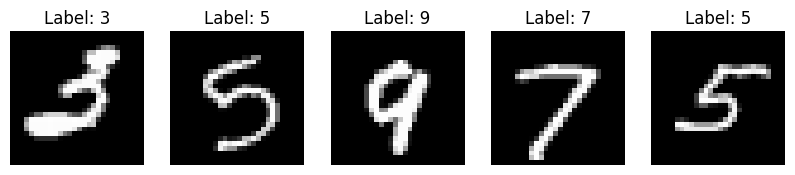

In [257]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axs[i].imshow(X_train[i], cmap="gray")
    axs[i].set_title(f"Label: {y_train[i]}")
    axs[i].axis("off")
plt.show()

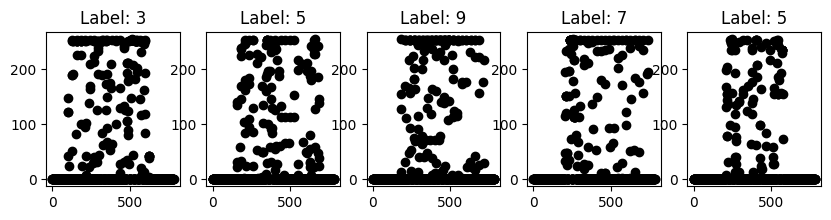

In [258]:
# how fnn see the data
# y-axis is the pixel value, x-axis is the pixel index

fig, axs = plt.subplots(1, 5, figsize=(10, 2))

for i in range(5):
    axs[i].plot(X_train[i, :].flatten(), "ko")
    axs[i].set_title(f"Label: {y_train[i]}")    
plt.show()

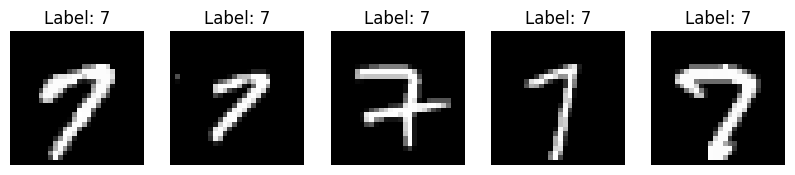

In [259]:
the7s = np.where(y == 7)[0]

fig, axs = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axs[i].imshow(X[the7s][i], cmap="gray")
    axs[i].set_title(f"Label: {y[the7s][i]}")    
    axs[i].axis("off")
plt.show()

There are 6265 7s in the whole data set (train + test).


Text(0.5, 1.0, 'Average 7')

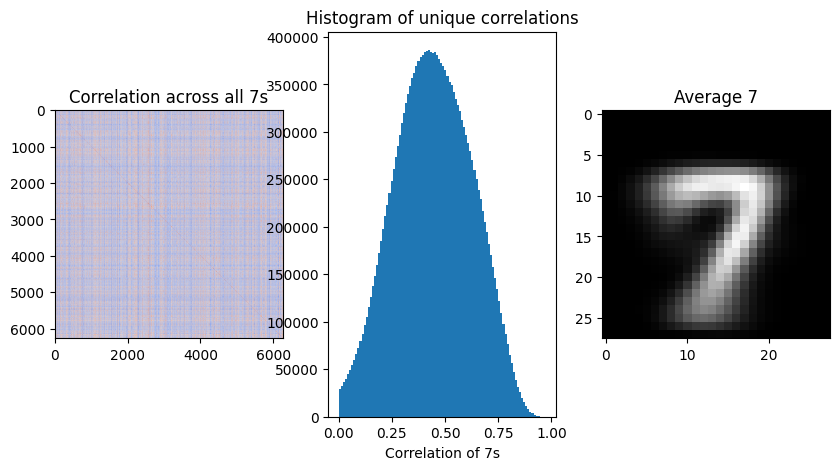

In [260]:
print(f"There are {len(the7s)} 7s in the whole data set (train + test).")

the7s_flatten = X[the7s, :, :].reshape(len(the7s), -1)
corr = np.corrcoef(the7s_flatten)

fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(corr, cmap="coolwarm", vmin=0, vmax=1)
ax[0].set_title("Correlation across all 7s")

# extract the unique correlations --> gettting the upper triangle of the correlation matrix, excluding the diagonal (k=1)
# if we see the distribution peak at 0.5, it means that on average, the 7s are 50% correlated with each other, which is pretty high
# if we see the distribution peak at 0, it means that on average, the 7s are not correlated with each other, which is pretty low
unique_corr = np.triu(corr, k=1).flatten()
unique_corr = unique_corr[unique_corr > 0]  # remove zeros
ax[1].hist(unique_corr, bins=100)
ax[1].set_title("Histogram of unique correlations")
ax[1].set_xlabel("Correlation of 7s")

# show all 7's together
average_7 = np.mean(X[the7s, :, :].numpy(), axis=0)
ax[2].imshow(average_7, cmap="gray")
ax[2].set_title("Average 7")

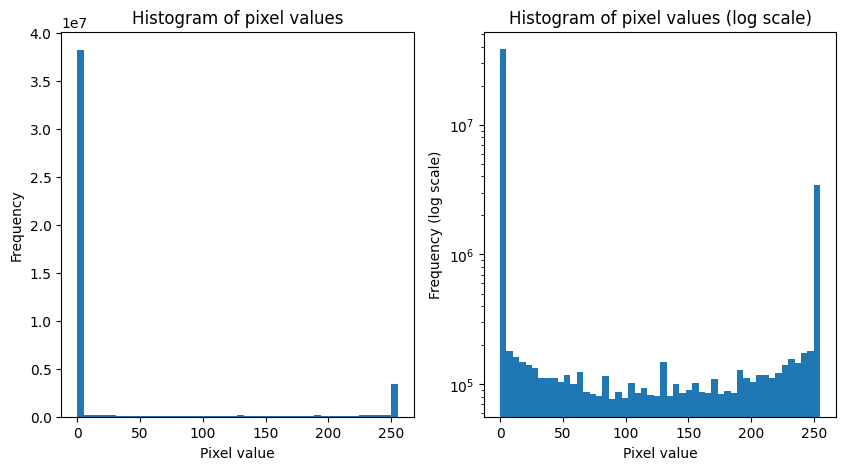

In [261]:
fig, ax = plt.subplots(1,2 , figsize=(10, 5))
ax[0].hist(X.flatten(), bins=50)
ax[0].set_title("Histogram of pixel values")
ax[0].set_xlabel("Pixel value")
ax[0].set_ylabel("Frequency")
ax[1].hist(X.flatten(), bins=50, log=True)
ax[1].set_title("Histogram of pixel values (log scale)")
ax[1].set_xlabel("Pixel value")
ax[1].set_ylabel("Frequency (log scale)")
plt.show()

In [279]:
# since data is already in the range of 0-255, we can just divide by 255 to get it in the range of 0-1
# this is min-max normalization since min value is 0 and max value is 255 --> xnorm = (x - min) / (max - min) = (x - 0) / (255 - 0)
X_train = X_train / 255.0
X_test = X_test /  255.0

In [263]:
# if we want to test how the model performs with binary data, we can round the pixel values to 0 or 1
# X_train = X_train.round()
# X_test = X_test.round()

In [264]:
# Convert into pytorch tensors
train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

batch_size = 32
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
test_dl = DataLoader(test_ds, batch_size=test_ds.tensors[0].shape[0], shuffle=False)

In [265]:
class MNIST_FNN(nn.Module):
    def __init__(self):
        super().__init__()
        # input layer it is not explicitly defined here since it doesn't have any parameters, but it has 28*28 "neurons" with no learnable parameters
        self.fc1 = nn.Linear(28*28, 64) # hidden layer, input 28*28 neurons (flattened image), output 64 neurons
        self.fc2 = nn.Linear(64, 32)    # hidden layer, input 64 neurons, output 32 neurons
        self.fc3 = nn.Linear(32, 32)    # hidden layer, input 32 neurons, output 32 neurons
        self.fc4 = nn.Linear(32, 10)    # output layer, input 32 neurons, output 10 neurons

    def forward(self, x):
        x = torch.flatten(x, start_dim=1) # flatten the image, keep the batch dimension
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = torch.log_softmax(self.fc4(x), dim=1) # log_softmax is used for numerical stability, it is equivalent to applying softmax and then taking the log
        return x

def train_one_epoch(model, train_dl, optimizer, loss_fn):
    model.train()
    batch_acc = []
    batch_loss = []
    for X_batch, y_batch in train_dl:
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        batch_acc_item = (output.argmax(dim=1) == y_batch).float().mean().item()
        batch_acc.append(batch_acc_item)
        batch_loss.append(loss.item())
        
    return np.mean(batch_acc), np.mean(batch_loss)

def train_model(model, train_dl, test_dl, optimizer, epochs):
    
    train_acc = torch.zeros(epochs)
    test_acc = torch.zeros(epochs)
    losses = torch.zeros(epochs)
    
    for epoch in range(epochs):
        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        
        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_acc[epoch] = (output.argmax(dim=1) == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses


In [266]:
learning_rate = 0.01
epochs = 50

model = MNIST_FNN()
loss_fn = nn.NLLLoss() # negative log likelihood loss, it is used for multi-class classification problems with log_softmax output
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  # we use SGD to slow down the learning and make it easier to distinguish the effects of different hyperparameters
    
train_acc, test_acc, losses = train_model(model, train_dl, test_dl, optimizer, epochs)

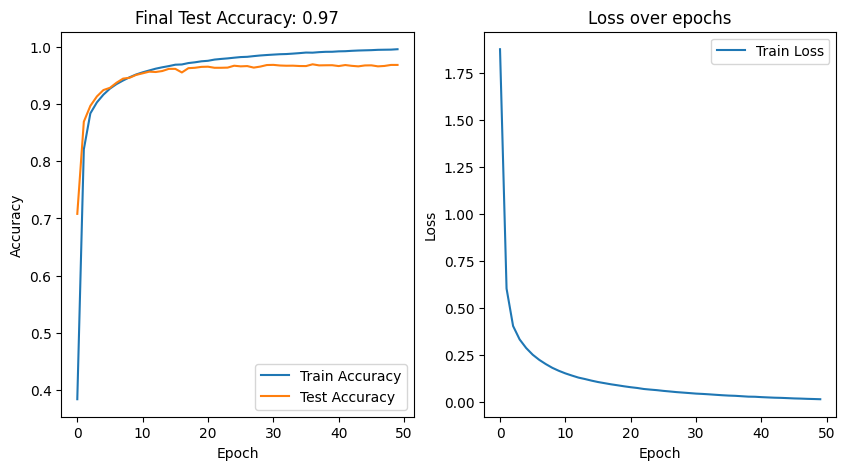

In [267]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(train_acc, label="Train Accuracy")
ax[0].plot(test_acc, label="Test Accuracy")
ax[0].set_title(f"Final Test Accuracy: {test_acc[-1]:.2f}")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[0].legend()

ax[1].plot(losses, label="Train Loss")
ax[1].set_title("Loss over epochs")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
plt.show()

/tmp/ipykernel_1688700/3724288299.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[1].bar(range(10), np.exp(predictions[random_pred]))


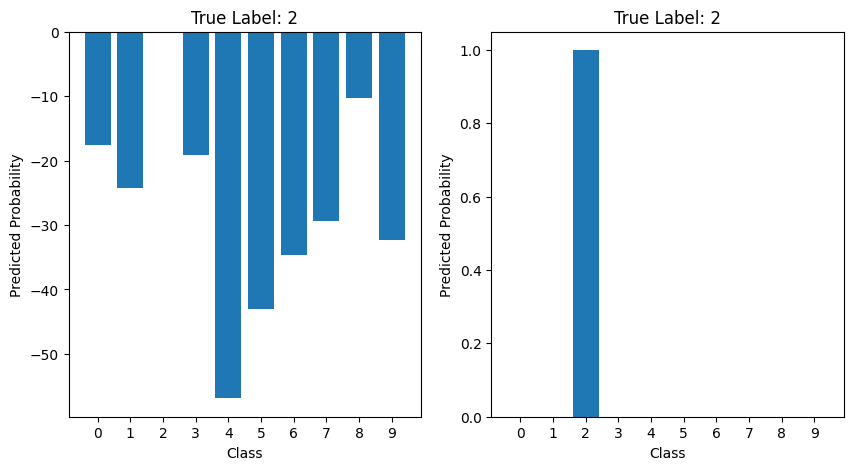

In [268]:
X_test, y_test = next(iter(test_dl))
predictions = model(X_test).detach()

# grab a random prediciton
random_pred = np.random.randint(0, len(X_test))

# plot in bars the predicted probabilities for each class
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].bar(range(10), predictions[random_pred])
ax[0].set_xticks(range(10))
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Predicted Probability")
ax[0].set_title(f"True Label: {y_test[random_pred].item()}")

ax[1].bar(range(10), np.exp(predictions[random_pred]))
ax[1].set_xticks(range(10))
ax[1].set_xlabel("Class")
ax[1].set_ylabel("Predicted Probability")
#ax[1].set_yscale("log")
ax[1].set_title(f"True Label: {y_test[random_pred].item()}")

plt.show()

/tmp/ipykernel_1688700/3975497566.py:16: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[1].bar(range(10), np.exp(predictions[random_incorrect]))


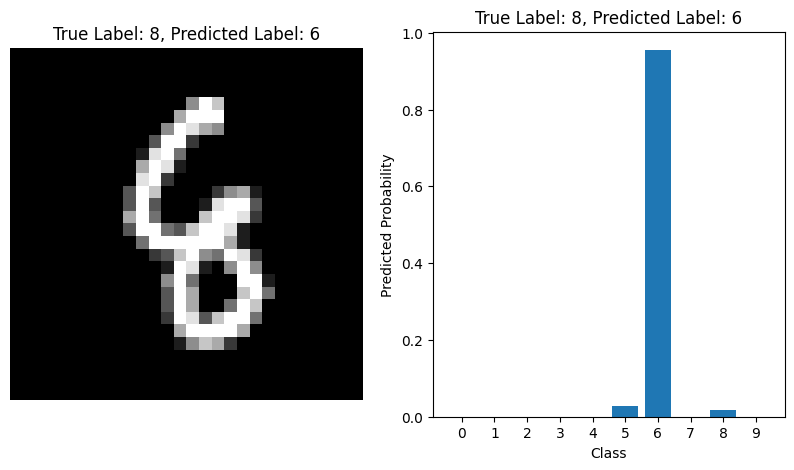

In [269]:
# find some examples where the model is wrong
X_test, y_test = next(iter(test_dl))
predictions = model(X_test).detach()
predicted_labels = predictions.argmax(dim=1)
incorrect_indices = (predicted_labels != y_test).nonzero(as_tuple=True)[0]

# grab a random incorrect prediction
np.random.seed(21)
random_incorrect = np.random.choice(incorrect_indices)

# plot the image of the number and the bar plot of the predicted probabilities for each class
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(X_test[random_incorrect].reshape(28, 28), cmap="gray")
ax[0].set_title(f"True Label: {y_test[random_incorrect].item()}, Predicted Label: {predicted_labels[random_incorrect].item()}")
ax[0].axis("off")
ax[1].bar(range(10), np.exp(predictions[random_incorrect]))
ax[1].set_xticks(range(10))
ax[1].set_xlabel("Class")
ax[1].set_ylabel("Predicted Probability")
ax[1].set_title(f"True Label: {y_test[random_incorrect].item()}, Predicted Label: {predicted_labels[random_incorrect].item()}")
plt.show()

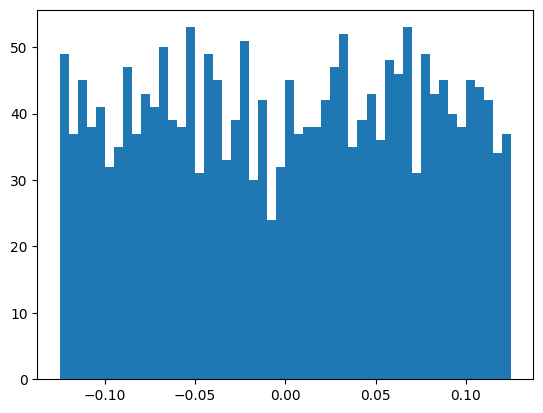

In [270]:
model = MNIST_FNN()

# initialization weights of the second layer
weights = model.fc2.weight.detach().numpy().flatten()

plt.hist(weights, bins=50)
plt.show()

In [271]:
np.histogram(weights, bins=10)

(array([210, 194, 221, 197, 179, 200, 216, 214, 215, 202]),
 array([-1.24842629e-01, -9.98687148e-02, -7.48947933e-02, -4.99208719e-02,
        -2.49469578e-02,  2.69562006e-05,  2.50008851e-02,  4.99747992e-02,
         7.49487132e-02,  9.99226272e-02,  1.24896556e-01], dtype=float32))

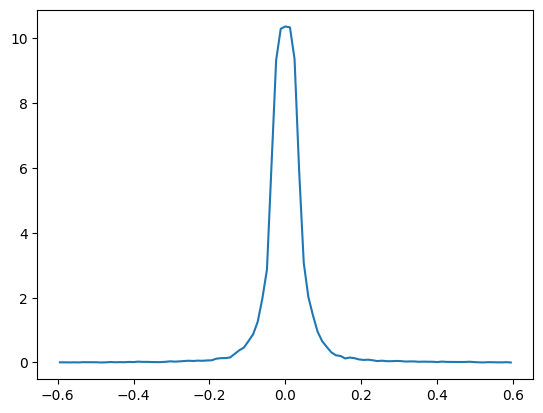

In [285]:
def histogram_of_weights(model, n_bins=50):
    W = np.array([])
    
    for layer in model.parameters():
        W = np.concatenate((W, layer.detach().numpy().flatten()))
        
    hist_freq, hist_val = np.histogram(W, bins=np.linspace(-0.6, 0.6, n_bins), density=True)
    hist_val = (hist_val[:-1] + hist_val[1:]) / 2  # to make them have the same length as hist_freq, otherwise we cannot plot them together
    return hist_val, hist_freq

hist_val, hist_freq = histogram_of_weights(model, n_bins=100)
plt.plot(hist_val, hist_freq)

In [286]:
def train_model_histogram(model, train_dl, test_dl, optimizer, epochs, n_bins):
    
    train_acc = torch.zeros(epochs)
    test_acc = torch.zeros(epochs)
    losses = torch.zeros(epochs)
    histogram_freq = torch.zeros(epochs, n_bins-1) # n_bins is the number of bins in the histogram

    for epoch in range(epochs):
        train_acc[epoch], losses[epoch] = train_one_epoch(model, train_dl, optimizer, loss_fn)
        hist_val, hist_freq = histogram_of_weights(model, n_bins)
        histogram_freq[epoch] = torch.tensor(hist_freq)

        model.eval()
        with torch.no_grad():
            for X_batch, y_batch in test_dl:
                output = model(X_batch)
                test_acc[epoch] = (output.argmax(dim=1) == y_batch).float().mean().item()
                
    return train_acc, test_acc, losses, hist_val, histogram_freq

In [ ]:
learning_rate = 0.01
epochs = 100
n_bins = 100

model = MNIST_FNN()
loss_fn = nn.NLLLoss() # negative log likelihood loss, it is used for multi-class classification problems with log_softmax output
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)  # we use SGD to slow down the learning and make it easier to distinguish the effects of different hyperparameters

batch_size = 32
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
test_dl = DataLoader(test_ds, batch_size=test_ds.tensors[0].shape[0], shuffle=False)
    
train_acc, test_acc, losses, hist_val, histogram_freq = train_model_histogram(model, train_dl, test_dl, optimizer, epochs, n_bins)

Text(0.5, 1.0, 'Histogram of weights over epochs')

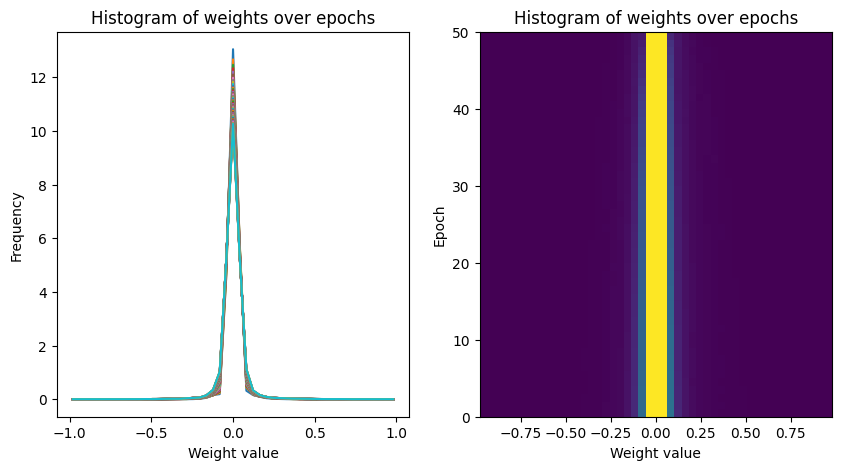

In [277]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for i in range(histogram_freq.shape[0]):
    ax[0].plot(hist_val, histogram_freq[i], label=f"Epoch {i+1}")
ax[0].set_xlabel("Weight value")
ax[0].set_ylabel("Frequency")
ax[0].set_title("Histogram of weights over epochs")
    
ax[1].imshow(histogram_freq, vmin=0, vmax=3, extent=[hist_val[0], hist_val[-1], 0, histogram_freq.shape[0]], aspect="auto")
ax[1].set_xlabel("Weight value")
ax[1].set_ylabel("Epoch")
ax[1].set_title("Histogram of weights over epochs")